In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mpl.rcParams['agg.path.chunksize'] = 100000

In [3]:
def _read_TemperatureData(loc_df, fname, protein, ensemble, coupling=None, nsnaps=1000000):
    
    sim_TEMPDF = pd.DataFrame(index=np.arange(1, nsnaps+1, 1), columns=loc_df.index.values).fillna(0.0)
    
    for rind in loc_df.index:
    
        if ensemble == 'NVE':
            temp_tseries = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, ensemble)], fname),
                                        delim_whitespace=True, usecols=[2,3,4,5,6,7,8])
            
        elif ensemble == 'NVT':
            temp_tseries = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, coupling)] ,fname),
                                       delim_whitespace=True, usecols=[2,3,4,5,6,7,8])
        print(rind)
        split_mask = temp_tseries['=.1'] != '='
        
        temp_tseries_extract = pd.DataFrame(index=temp_tseries.index, columns=['TIME(PS)','TEMP(K)'])
        temp_tseries_extract.loc[temp_tseries[~split_mask].index, 'TIME(PS)'] = temp_tseries[~split_mask].iloc[:,3].astype('float64')
        temp_tseries_extract.loc[temp_tseries[~split_mask].index, 'TEMP(K)'] = temp_tseries[~split_mask].iloc[:,6].astype('float64')
        
        temp_tseries_extract.loc[temp_tseries[split_mask].index,'TIME(PS)'] = temp_tseries[split_mask].iloc[:-2,2].astype('float64')
        temp_tseries_extract.loc[temp_tseries[split_mask].index,'TEMP(K)'] = temp_tseries[split_mask].iloc[:-2,5].astype('float64')
        temp_tseries_extract = temp_tseries_extract.dropna()
        
        if temp_tseries_extract.shape[0] >= nsnaps:
            sim_TEMPDF.loc[:, rind] = temp_tseries_extract['TEMP(K)'].values[0:nsnaps]
        else:
            sim_TEMPDF.loc[temp_tseries_extract.index.values+1, rind] = temp_tseries_extract['TEMP(K)'].values
        
    return sim_TEMPDF

In [4]:
def _read_TemperatureData_wChk(loc_df, fname, protein, ensemble, coupling=None, nsnaps=1000000):
    
    sim_TEMPDF = pd.DataFrame(index=np.arange(1, nsnaps+1, 1), columns=loc_df.index.values).fillna(0.0)
    
    for rind in loc_df.index:
    
        if ensemble == 'NVE':
            temp_tseries = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, ensemble)], fname),
                                        delim_whitespace=True, usecols=[2,3,4,5,6,7,8])
            
        elif ensemble == 'NVT':
            temp_tseries = pd.read_csv('{}/{}'.format(loc_df.loc[rind,(protein, coupling)] ,fname),
                                       delim_whitespace=True, usecols=[2,3,4,5,6,7,8])
        print(rind)
        temp_tseries_extract = pd.DataFrame(index=temp_tseries.index, columns=['TIME(PS)','TEMP(K)'])
    
        ## Error Checking to Make sure 
        while True:
            try:
                split_mask = temp_tseries['=.1'] != '='
        
                fconv=3
                temp_tseries_extract.loc[temp_tseries[~split_mask].index, 'TIME(PS)'] = temp_tseries[~split_mask].iloc[:,fconv].astype('float64')
                fconv=6
                temp_tseries_extract.loc[temp_tseries[~split_mask].index, 'TEMP(K)'] = temp_tseries[~split_mask].iloc[:,fconv].astype('float64')
        
                fconv=2 ## TEMPDATA
                temp_tseries_extract.loc[temp_tseries[split_mask].index,'TIME(PS)'] = temp_tseries[split_mask].iloc[:-2,fconv].astype('float64')
                fconv=5 ## TEMPDATA
                temp_tseries_extract.loc[temp_tseries[split_mask].index,'TEMP(K)'] = temp_tseries[split_mask].iloc[:-2,fconv].astype('float64')
        
                break;
    
            except ValueError as verr:
                print('incorrect value in tseries: Can not convert to float')
                print(verr)
                interupt = str(verr).split(':')[-1] 
                interupt_mask = temp_tseries[split_mask].iloc[:,fconv][temp_tseries[split_mask].iloc[:,fconv] == str(interupt)[2:-1]].index
        
                temp_tseries = temp_tseries.drop(interupt_mask)
        
        temp_tseries_extract = temp_tseries_extract.dropna()
        if temp_tseries_extract.shape[0] >= nsnaps:
            sim_TEMPDF.loc[:, rind] = temp_tseries_extract['TEMP(K)'].values[0:nsnaps]
        else:
            sim_TEMPDF.loc[temp_tseries_extract.index.values+1, rind] = temp_tseries_extract['TEMP(K)'].values
        
    return sim_TEMPDF

In [5]:
temp_tseries_extract = pd.DataFrame(index=TEMP_NVT.index, columns=['TIME(PS)','TEMP(K)'])

while True:
    try:
        split_mask = TEMP_NVT['=.1'] != '='
        
        fconv=3
        temp_tseries_extract.loc[TEMP_NVT[~split_mask].index, 'TIME(PS)'] = TEMP_NVT[~split_mask].iloc[:,fconv].astype('float64')
        fconv=6
        temp_tseries_extract.loc[TEMP_NVT[~split_mask].index, 'TEMP(K)'] = TEMP_NVT[~split_mask].iloc[:,fconv].astype('float64')
        
        fconv=2 ## TEMPDATA
        temp_tseries_extract.loc[TEMP_NVT[split_mask].index,'TIME(PS)'] = TEMP_NVT[split_mask].iloc[:-2,fconv].astype('float64')
        fconv=5 ## TEMPDATA
        temp_tseries_extract.loc[TEMP_NVT[split_mask].index,'TEMP(K)'] = TEMP_NVT[split_mask].iloc[:-2,fconv].astype('float64')
        
        break;
    
    except ValueError as verr:
        print('incorrect value in tseries: Can not convert to float')
        print(verr)
        interupt = str(verr).split(':')[-1] 
        interupt_mask = TEMP_NVT[split_mask].iloc[:,fconv][TEMP_NVT[split_mask].iloc[:,fconv] == str(interupt)[2:-1]].index
        
        TEMP_NVT = TEMP_NVT.drop(interupt_mask)

NameError: name 'TEMP_NVT' is not defined

In [5]:
def _readfwf_TemperatureData(loc_df, fname, protein, ensemble, coupling=None, nsnaps=1000000):
    
    sim_TEMPDF = pd.DataFrame(index=np.arange(1, nsnaps+1, 1), columns=loc_df.index.values).fillna(0.0)
    
    for rind in loc_df.index:
    
        if ensemble == 'NVE':
            temp_tseries = pd.read_fwf('{}/{}'.format(loc_df.loc[rind,(protein, ensemble)], fname), header=None)
            
        elif ensemble == 'NVT':
            temp_tseries = pd.read_fwf('{}/{}'.format(loc_df.loc[rind,(protein, coupling)] ,fname), header=None)
        print(rind)
        split_mask = temp_tseries['=.1'] != '='
        
        temp_tseries_extract = pd.DataFrame(index=temp_tseries.index, columns=['TIME(PS)','TEMP(K)'])
        temp_tseries_extract.loc[temp_tseries[~split_mask].index, 'TIME(PS)'] = temp_tseries[~split_mask].iloc[:,3].astype('float64')
        temp_tseries_extract.loc[temp_tseries[~split_mask].index, 'TEMP(K)'] = temp_tseries[~split_mask].iloc[:,6].astype('float64')
        
        temp_tseries_extract.loc[temp_tseries[split_mask].index,'TIME(PS)'] = temp_tseries[split_mask].iloc[:-2,2].astype('float64')
        temp_tseries_extract.loc[temp_tseries[split_mask].index,'TEMP(K)'] = temp_tseries[split_mask].iloc[:-2,5].astype('float64')
        temp_tseries_extract = temp_tseries_extract.dropna()
        
        if temp_tseries_extract.shape[0] >= nsnaps:
            sim_TEMPDF.loc[:, rind] = temp_tseries_extract['TEMP(K)'].values[0:nsnaps]
        else:
            sim_TEMPDF.loc[temp_tseries_extract.index.values+1, rind] = temp_tseries_extract['TEMP(K)'].values
        
    return sim_TEMPDF

In [6]:
CorrFuncLOC = 'E:/Users/Alan/Documents/Research/DiffusionTip4pDSoluteSize/'
CorrFuncLoc2 = 'D:/Research/LangevinDynamics_RotationalDiffusion/'
ENSEMBLES = ['NVE', 'NVT']
CouplingFrequency = ['CF0-2ps', 'CF2ps', 'CF20ps']
RUNS = ['Run{}'.format(n) for n in range(1,5,1)]
Proteins = ['GB3', 'Ubiquitin']
MINDX = pd.MultiIndex.from_product([Proteins, ENSEMBLES])
MINDX_NVT=pd.MultiIndex.from_product([Proteins, CouplingFrequency])
LocDF_NVE = pd.DataFrame(index=RUNS, columns=MINDX)
LocDF_NVE_R2 = LocDF_NVE.copy()
LocDF_NVT = pd.DataFrame(index=RUNS, columns=MINDX_NVT)
FileLocDict = {}

In [7]:
for items, values in LocDF_NVT.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVT.loc[indx, items] = '{}{}/PROD_NVT/{}/{}'.format(CorrFuncLoc2, items[0], items[1], indx)
        
for items, values in LocDF_NVE.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE.loc[indx, items] = '{}{}/PROD_{}/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'CF0-2ps')
('GB3', 'CF2ps')
('GB3', 'CF20ps')
('Ubiquitin', 'CF0-2ps')
('Ubiquitin', 'CF2ps')
('Ubiquitin', 'CF20ps')
('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [8]:
for items, values in LocDF_NVE_R2.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE_R2.loc[indx, items] = '{}{}/PROD_{}_Run2/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [9]:
LocDF_NVE_R3 = LocDF_NVE.copy()
for items, values in LocDF_NVE_R3.iteritems():
    print(items)
    for indx, loc in values.iteritems():
        LocDF_NVE_R3.loc[indx, items] = '{}{}/PROD_{}_Run3/{}'.format(CorrFuncLoc2, items[0], items[1], indx)

('GB3', 'NVE')
('GB3', 'NVT')
('Ubiquitin', 'NVE')
('Ubiquitin', 'NVT')


In [10]:
DIR = 'D:/Research/LangevinDynamics_RotationalDiffusion/GB3/PROD_NVT/CF0-2ps/'
RUNS = ['Run{}'.format(nr) for nr in range(1,5,1)]

In [11]:
GB3_TEMP_NVE = _read_TemperatureData_wChk(LocDF_NVE, 'TEMP_MDOUT.dat', 'GB3', 'NVE', coupling=None, nsnaps=1000000)
GB3_TEMP_NVE_R2 = _read_TemperatureData_wChk(LocDF_NVE_R2, 'TEMP_MDOUT.dat', 'GB3', 'NVE', coupling=None, nsnaps=1000000)
UBQ_TEMP_NVE = _read_TemperatureData_wChk(LocDF_NVE, 'TEMP_MDOUT.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000)
UBQ_TEMP_NVE_R2 = _read_TemperatureData_wChk(LocDF_NVE_R2, 'TEMP_MDOUT.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000)
UBQ_TEMP_NVE_R3 = _read_TemperatureData_wChk(LocDF_NVE_R3, 'TEMP_MDOUT.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000)

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\interactiveshell.py:3254: DtypeWarning: Columns (2,4,5,7,8) have mixed types.Specify dtype option on import or set low_memory=False.
  if (await self.run_code(code, result,  async_=asy)):


Run1
Run2
Run3
Run4
Run1
Run2
Run3
Run4
Run1
Run2
Run3
Run4
Run1
Run2
Run3
Run4
Run1
Run2
Run3
Run4


In [12]:
GB3_TEMP_NVT_Cf2ps = _read_TemperatureData_wChk(LocDF_NVT, 'TEMP_MDOUT.dat', 'GB3', 'NVT', coupling='CF2ps', nsnaps=1000000)

Run1
Run2
Run3
incorrect value in tseries: Can not convert to float
could not convert string to float: 'TIME(PS)'
Run4
incorrect value in tseries: Can not convert to float
could not convert string to float: '='


In [13]:
GB3_TEMP_NVT_Cf20ps = _read_TemperatureData_wChk(LocDF_NVT, 'TEMP_MDOUT.dat', 'GB3', 'NVT', coupling='CF20ps', nsnaps=1000000)

Run1
Run2
incorrect value in tseries: Can not convert to float
could not convert string to float: '1-4'
Run3
Run4


In [14]:
UBQ_TEMP_NVT_Cf02ps = _read_TemperatureData_wChk(LocDF_NVT, 'TEMP_MDOUT.dat', 'Ubiquitin', 'NVT', coupling='CF0-2ps', nsnaps=1000000)
UBQ_TEMP_NVT_Cf2ps = _read_TemperatureData_wChk(LocDF_NVT, 'TEMP_MDOUT.dat', 'Ubiquitin', 'NVT', coupling='CF2ps', nsnaps=1000000)
UBQ_TEMP_NVT_Cf20ps = _read_TemperatureData_wChk(LocDF_NVT, 'TEMP_MDOUT.dat', 'Ubiquitin', 'NVT', coupling='CF20ps', nsnaps=1000000)

Run1
Run2
Run3
Run4
incorrect value in tseries: Can not convert to float
could not convert string to float: '1-4'
incorrect value in tseries: Can not convert to float
could not convert string to float: '=127854500'
Run1
Run2
Run3
Run4
Run1
Run2
Run3
Run4


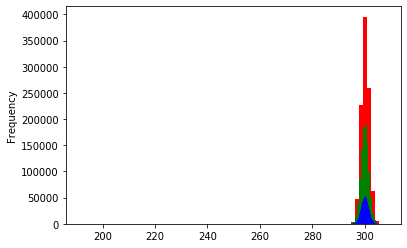

In [15]:
UBQ_TEMP_NVT_Cf02ps.loc[1:, 'Run1'].plot.hist(bins=75, color='r')
UBQ_TEMP_NVT_Cf2ps.loc[1:, 'Run1'].plot.hist(bins=75, color='g')
UBQ_TEMP_NVT_Cf20ps.loc[1:,'Run1'].plot.hist(bins=75, color='b')

In [16]:
GB3_TEMP_NVT_Cf2ps

,Run1,Run2,Run3,Run4
1,249.08,250.21,254.05,247.86
2,279.65,279.36,278.7,281.27
3,288.07,290.69,287.52,289.16
4,293.64,298.53,296.05,295.53
5,294.34,296.82,296.15,297.41
...,...,...,...,...
999996,301.04,301.18,301.18,302.74
999997,302.76,302.55,299.63,301.92
999998,301.14,299.05,297.99,300.6
999999,300.96,297.56,299.41,299.86


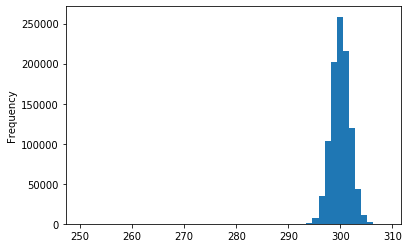

In [17]:
GB3_TEMP_NVT_Cf2ps['Run2'].plot.hist(bins=50)

In [ ]:
indx_bad = UBQ_TEMP_NVE['Run2'][(UBQ_TEMP_NVE['Run2']>350) | (UBQ_TEMP_NVE['Run2']<200) ].index

UBQ_TEMP_NVE.loc[indx_bad,'Run2'] = np.nan 


In [ ]:
UBQ_TEMP_NVE.plot.hist(subplots=True,bins=75, fill=False)


In [13]:
GB3_TEMP_NVE[]

,Run1,Run2,Run3,Run4
1,304.89,300.21,302.66,300.35
2,301.94,301.52,305.27,300.93
3,305.31,301.55,302.06,300.32
4,300.95,303.64,301.95,300.73
5,303.8,301.7,301.69,301.01
...,...,...,...,...
999996,316.11,314.8,0,299.21
999997,313.76,314.17,0,301.6
999998,314.05,311.84,0,303.32
999999,313.02,313.88,0,307.06


In [18]:
GB3_TEMP_NVE['Run3'] = GB3_TEMP_NVE['Run3'].replace({0.0:np.nan})

In [19]:
GB3_TEMP_NVE['Time'] = GB3_TEMP_NVE.index*0.0005

In [20]:
def _plot_TempMarg(tempdata):
    
    fig_gs = plt.figure(3131, figsize=(10,8))
    grid_spec = GridSpec(4,9)

    axseries = fig_gs.add_subplot(grid_spec[0:3,0:7])
    axhist = fig_gs.add_subplot(grid_spec[0:3,7:9])
    
    tempdata.plot(x='Time',ax=axseries)
    tempdata[['Run1','Run2','Run3','Run4']].plot.hist(bins=75, orientation='horizontal',
                                                      fill=True, ax=axhist, alpha=0.5, legend=False)

    plt.setp(axhist.get_yticklabels(), visible=False)
    axhist.set_xlabel('Frequency',weight='bold',fontsize=14)
    axhist.tick_params(labelsize=14)

    axseries.set_ylabel('Temperature (K)', weight='bold', fontsize=14)
    axseries.set_xlabel('Time (ns)', weight='bold', fontsize=14)
    axseries.set_xticks(np.arange(0,550,50))
    axseries.set_xticks(np.arange(0,550,25), minor=True)
    axseries.tick_params(labelsize=14)
    axseries.legend(frameon=False, prop={'size':15,'weight':'bold'})
    
    return fig_gs

In [21]:
def _plot_TempMarg_hist(tempdata, histbins):
    
    fig_gs = plt.figure(3131, figsize=(10,8))
    grid_spec = GridSpec(4,9)

    axseries = fig_gs.add_subplot(grid_spec[0:3,0:7])
    axhist = fig_gs.add_subplot(grid_spec[0:3,7:9])
    colors = sns.color_palette('Dark2', tempdata.shape[1])
    
    #tempdata.plot(x='Time', ax=axseries, c=colors)
    
    hist_cf_list = []
    
    for Tdata in RUNS:
        hist_cf, edges = np.histogram(tempdata[Tdata].values, bins=histbins, density=True)
        hist_cf_list.append(hist_cf)

    edges = 0.5*(histbins[1:]+histbins[:-1])
    
    for hists, col, lbls in zip(hist_cf_list, colors, RUNS):
        tempdata[[lbls,'Time']].plot(x='Time', y=lbls, ax=axseries, c=col)
        axhist.plot(hists, edges, c=col, label=lbls, linewidth=2)
    

    plt.setp(axhist.get_yticklabels(), visible=False)
    axhist.set_xlabel('Density',weight='bold',fontsize=14)
    axhist.tick_params(labelsize=14)

    axseries.set_ylabel('Temperature (K)', weight='bold', fontsize=14)
    axseries.set_xlabel('Time (ns)', weight='bold', fontsize=14)
    axseries.set_xticks(np.arange(0, 550, 50))
    axseries.set_xticks(np.arange(0, 550, 25), minor=True)
    
    axseries.set_ylim(histbins[0], histbins[-1])
    axseries.set_yticks(np.arange(histbins[0], histbins[-1], 2.5), minor=True)
    axseries.set_yticks(np.arange(histbins[0], histbins[-1], 5))
    
    axhist.set_ylim(histbins[0], histbins[-1])
    axhist.set_yticks(np.arange(histbins[0], histbins[-1], 2.5), minor=True)
    axhist.set_yticks(np.arange(histbins[0], histbins[-1], 5))
    
    axseries.tick_params(labelsize=14)
    axseries.legend(frameon=False, prop={'size':15,'weight':'bold'})
    
    return fig_gs

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


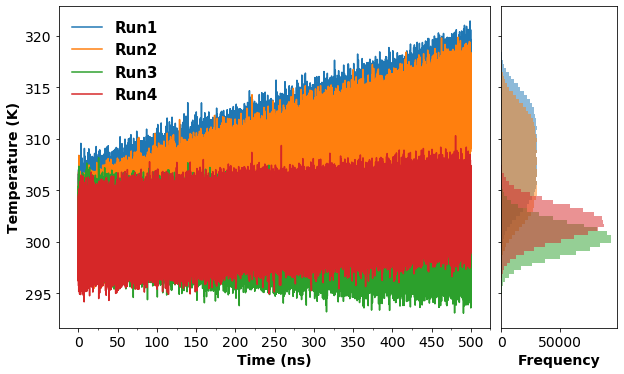

In [18]:
fig_gs = plt.figure(3131, figsize=(10,8))
grid_spec = GridSpec(4,9)

tseries = fig_gs.add_subplot(grid_spec[0:3,0:7])
marg_hist = fig_gs.add_subplot(grid_spec[0:3,7:9])

GB3_TEMP_NVE.plot(x='Time',ax=tseries)
GB3_TEMP_NVE[['Run1','Run2','Run3','Run4']].plot.hist(bins=75, orientation='horizontal',
                                                      fill=True, ax=marg_hist, alpha=0.5, legend=False)

plt.setp(marg_hist.get_yticklabels(), visible=False)
marg_hist.set_xlabel('Frequency',weight='bold',fontsize=14)
marg_hist.tick_params(labelsize=14)

tseries.set_ylabel('Temperature (K)', weight='bold', fontsize=14)
tseries.set_xlabel('Time (ns)', weight='bold', fontsize=14)
tseries.set_xticks(np.arange(0,550,50))
tseries.set_xticks(np.arange(0,550,25), minor=True)
tseries.tick_params(labelsize=14)
tseries.legend(frameon=False, prop={'size':15,'weight':'bold'})


fig_gs.savefig('{}/GB3/Analysis/NVE_Run1_Temperature_Tseries_HistMarg.png'.format(CorrFuncLoc2),
               dpi=600, bbox_inches='tight')

In [13]:
GB3_TEMP_NVE_R2['Time'] = GB3_TEMP_NVE_R2.index*0.0005

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


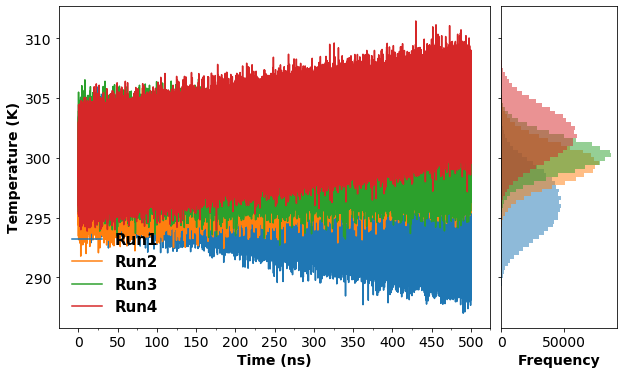

In [14]:
fig_gs = plt.figure(3133, figsize=(10,8))
grid_spec = GridSpec(4,9)

tseries = fig_gs.add_subplot(grid_spec[0:3,0:7])
marg_hist = fig_gs.add_subplot(grid_spec[0:3,7:9])

GB3_TEMP_NVE_R2.plot(x='Time',ax=tseries)
GB3_TEMP_NVE_R2[['Run1','Run2','Run3','Run4']].plot.hist(bins=75, orientation='horizontal',
                                                      fill=True, ax=marg_hist, alpha=0.5, legend=False)

plt.setp(marg_hist.get_yticklabels(), visible=False)
marg_hist.set_xlabel('Frequency',weight='bold',fontsize=14)
marg_hist.tick_params(labelsize=14)

tseries.set_ylabel('Temperature (K)', weight='bold', fontsize=14)
tseries.set_xlabel('Time (ns)', weight='bold', fontsize=14)
tseries.set_xticks(np.arange(0,550,50))
tseries.set_xticks(np.arange(0,550,25), minor=True)
tseries.tick_params(labelsize=14)
tseries.legend(frameon=False, prop={'size':15,'weight':'bold'})

fig_gs.savefig('{}/GB3/Analysis/NVE_Run2_Temperature_Tseries_HistMarg.png'.format(CorrFuncLoc2),
               dpi=600, bbox_inches='tight')

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  after removing the cwd from sys.path.
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


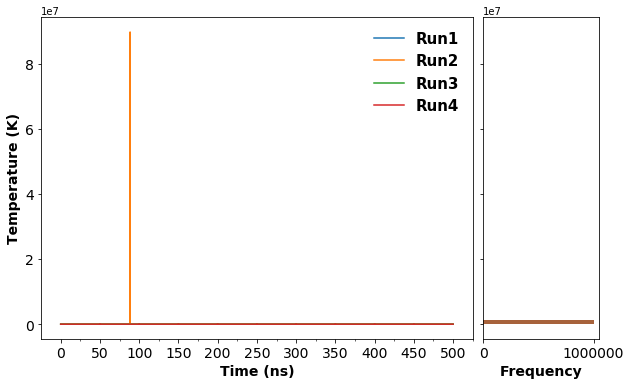

In [17]:
UBQ_TEMP_NVE['Time'] = UBQ_TEMP_NVE.index*0.0005
ubq_fig_gsR1 = _plot_TempMarg(UBQ_TEMP_NVE)
ubq_fig_gsR1.savefig('{}/Ubiquitin/Analysis/NVE_Run1_Temperature_Tseries_HistMarg.png'.format(CorrFuncLoc2),
                     dpi=660, bbox_inches='tight')

In [20]:
UBQ_TEMP_NVE

,Run1,Run2,Run3,Run4,Time
1,297.09,299.73,296.04,299.82,0.0005
2,298.58,299.54,299.74,300.25,0.0010
3,297.66,297.4,299.26,300.03,0.0015
4,297.19,299.37,299.13,300.98,0.0020
5,298.64,300.83,297.49,303.52,0.0025
...,...,...,...,...,...
999996,299.95,0,291.14,318.49,499.9980
999997,299.02,0,291.83,317.13,499.9985
999998,299.28,0,291.79,317.54,499.9990
999999,298.26,0,289.49,316.49,499.9995


C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  after removing the cwd from sys.path.
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


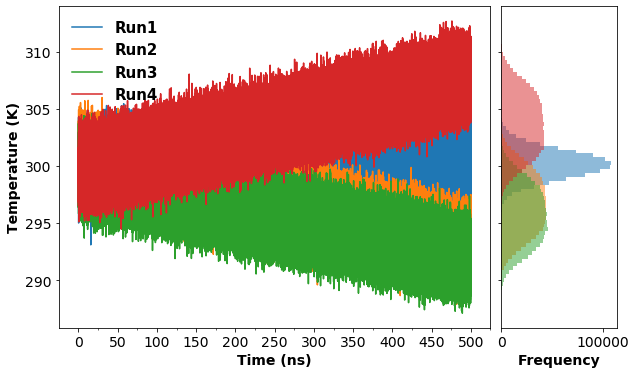

In [17]:
UBQ_TEMP_NVE_R2['Time'] = UBQ_TEMP_NVE_R2.index*0.0005
ubq_fig_gsR2 = _plot_TempMarg(UBQ_TEMP_NVE_R2)
ubq_fig_gsR2.savefig('{}/Ubiquitin/Analysis/NVE_Run2_Temperature_Tseries_HistMarg.png'.format(CorrFuncLoc2),
                     dpi=660, bbox_inches='tight')

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


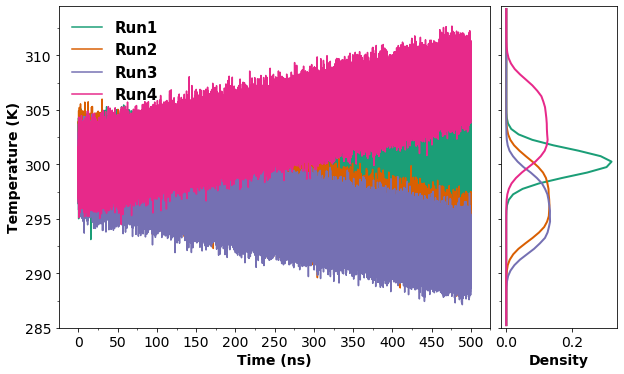

In [34]:
ubq_fig_gsR2_hst = _plot_TempMarg_hist(UBQ_TEMP_NVE_R2, np.arange(285,315,0.5))
ubq_fig_gsR2_hst.savefig('{}/Ubiquitin/Analysis/NVE_Run2_Temperature_Tseries_HistMarg_LinePlot.png'.format(CorrFuncLoc2),
                     dpi=660, bbox_inches='tight')

In [ ]:
_plot_TempMarg_hist

In [ ]:
UBQ_TEMP_NVE_R2.mean()

In [ ]:
UBQ_TEMP_NVE_R3 = _read_TemperatureData(LocDF_NVE_R3, 'TEMP_MDOUT.dat', 'Ubiquitin', 'NVE', coupling=None, nsnaps=1000000)

In [ ]:
UBQ_TEMP_NVE_R3['Time'] = UBQ_TEMP_NVE_R3.index*0.0005
ubq_fig_gsR3 = _plot_TempMarg(UBQ_TEMP_NVE_R3)
ubq_fig_gsR3.savefig('{}/Ubiquitin/Analysis/NVE_Run3_Temperature_Tseries_HistMarg.png'.format(CorrFuncLoc2),
                     dpi=660, bbox_inches='tight')

In [ ]:
UBQ_TEMP_NVE_R3.mean()

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  after removing the cwd from sys.path.
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


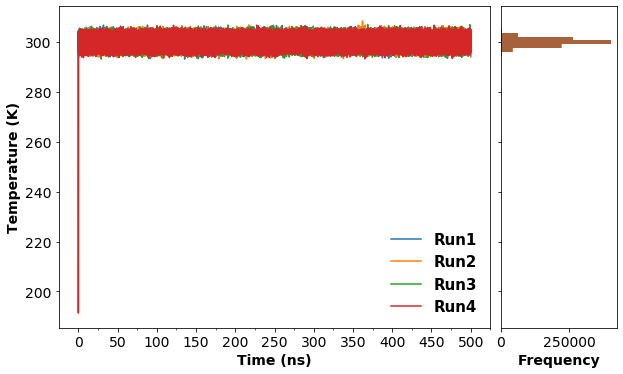

In [39]:
UBQ_TEMP_NVT_Cf02ps['Time'] = UBQ_TEMP_NVT_Cf02ps.index*0.0005
ubq_fig_gsNVT02 = _plot_TempMarg(UBQ_TEMP_NVT_Cf02ps)
ubq_fig_gsNVT02.savefig('{}/Ubiquitin/Analysis/NVT_Cf0-2ps_Temperature_Tseries_HistMarg.png'.format(CorrFuncLoc2),
                     dpi=660, bbox_inches='tight')

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  after removing the cwd from sys.path.
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


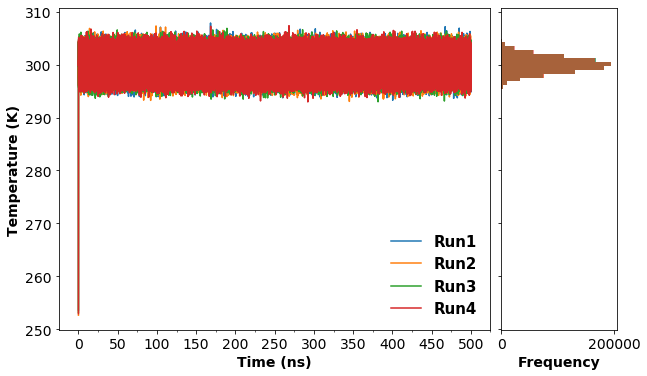

In [40]:
UBQ_TEMP_NVT_Cf2ps['Time'] = UBQ_TEMP_NVT_Cf2ps.index*0.0005
ubq_fig_gsNVT = _plot_TempMarg(UBQ_TEMP_NVT_Cf2ps)
ubq_fig_gsNVT.savefig('{}/Ubiquitin/Analysis/NVT_Cf2ps_Temperature_Tseries_HistMarg.png'.format(CorrFuncLoc2),
                     dpi=660, bbox_inches='tight')

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  after removing the cwd from sys.path.
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


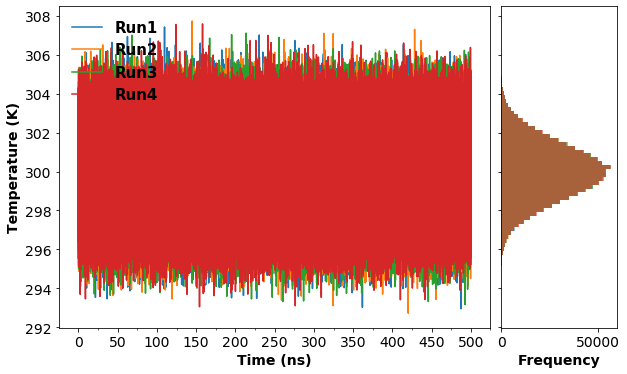

In [41]:
UBQ_TEMP_NVT_Cf20ps['Time'] = UBQ_TEMP_NVT_Cf20ps.index*0.0005
ubq_fig_gsNVT20 = _plot_TempMarg(UBQ_TEMP_NVT_Cf20ps)
ubq_fig_gsNVT20.savefig('{}/Ubiquitin/Analysis/NVT_Cf20ps_Temperature_Tseries_HistMarg.png'.format(CorrFuncLoc2),
                     dpi=660, bbox_inches='tight')

In [22]:
def _plot_TempMarg_NVT(nvt_cf02ps, nvt_cf2ps, nvt_cf20ps):
    
    fig_gs = plt.figure(3133, figsize=(10,8))
    grid_spec = GridSpec(4,9)

    axseries = fig_gs.add_subplot(grid_spec[0:3,0:7])
    axhist = fig_gs.add_subplot(grid_spec[0:3,7:9])

    #nvt_cf02ps.iloc[50:][['Time','Run1']].plot(x='Time', ax=axseries, color='orange', label=r'$\mathbf{\zeta=0.2 \ \ ps^{-1}}$')
    nvt_cf2ps.iloc[50:][['Time','Run1']].plot(x='Time', ax=axseries, color='green', label=r'$\mathbf{\zeta=2 \ \ ps^{-1}}$')
    #nvt_cf20ps.iloc[50:][['Time','Run1']].plot(x='Time', ax=axseries, color='red', label=r'$\mathbf{\zeta=20 \ \ ps^{-1}}$')
    
    hist_bins = np.arange(290, 315, 0.5)
    hist_cf_list = []

    for Tdata in [nvt_cf02ps['Run1'].values, nvt_cf2ps['Run1'].values, nvt_cf20ps['Run1'].values]:
        hist_cf, edges = np.histogram(Tdata[50:], bins=hist_bins, density=True)
        hist_cf_list.append(hist_cf)

    cf_lbls = [r'$\mathbf{\zeta=0.2 ps^{-1}}$', r'$\mathbf{\zeta=2 ps^{-1}}$', r'$\mathbf{\zeta=20 ps^{-1}}$']
    edges = 0.5*(hist_bins[1:]+hist_bins[:-1])
    
    #for hists, colors, lbls in zip(hist_cf_list, ['orange','green','red'], cf_lbls) :
        #axhist.plot(hists, edges, c=colors, label=lbls, linewidth=2)
    
    axhist.plot(hist_cf_list[1], edges, c='green', label=cf_lbls[1], linewidth=2)
    #nvt_cf02ps['Run1'].plot.hist(bins=hist_bins, orientation='horizontal', color='orange',
    #                                                  fill=True, ax=axhist, alpha=0.5, legend=False)
    #nvt_cf2ps['Run1'].plot.hist(bins=hist_bins, orientation='horizontal', color='green',
    #                                                  fill=True, ax=axhist, alpha=0.5, legend=False)
    #nvt_cf20ps['Run1'].plot.hist(bins=hist_bins, orientation='horizontal', color='red',
    #                                                  fill=True, ax=axhist, alpha=0.5, legend=False)

    plt.setp(axhist.get_yticklabels(), visible=False)
    axhist.set_xlabel('Density',weight='bold',fontsize=14)
    axhist.tick_params(labelsize=14)

    axseries.set_ylabel('Temperature (K)', weight='bold', fontsize=14)
    axseries.set_xlabel('Time (ns)', weight='bold', fontsize=14)
    axseries.set_xticks(np.arange(0, 550, 50))
    axseries.set_xticks(np.arange(0, 550, 25), minor=True)
    
    axseries.set_ylim(hist_bins[0], hist_bins[-1])
    axseries.set_yticks(np.arange(hist_bins[0], hist_bins[-1], 2.5), minor=True)
    axseries.set_yticks(np.arange(hist_bins[0], hist_bins[-1], 5))
    
    axhist.set_ylim(hist_bins[0], hist_bins[-1])
    axhist.set_yticks(np.arange(hist_bins[0], hist_bins[-1], 2.5), minor=True)
    axhist.set_yticks(np.arange(hist_bins[0], hist_bins[-1], 5))

    
    axseries.tick_params(labelsize=14)
    axs_hndl, axs_lbls = axseries.get_legend_handles_labels()
    axseries.legend(axs_hndl, cf_lbls,
                    frameon=False, prop={'size':15,'weight':'bold'})
    
    return fig_gs

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:2: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


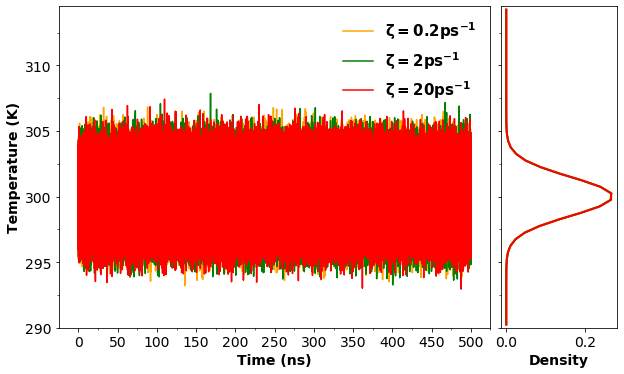

In [43]:
fig_nvt_comp = _plot_TempMarg_NVT(UBQ_TEMP_NVT_Cf02ps, UBQ_TEMP_NVT_Cf2ps, UBQ_TEMP_NVT_Cf20ps)
fig_nvt_comp.savefig('{}{}/Analysis/CompareNVT_TemperatureRegulation_CutStart.png'.format(CorrFuncLoc2,'Ubiquitin'), dpi=600, bbox_inches='tight')

C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\ipykernel_launcher.py:5: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  """
C:\Users\Alan\Anaconda3\envs\MDAnalysis\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


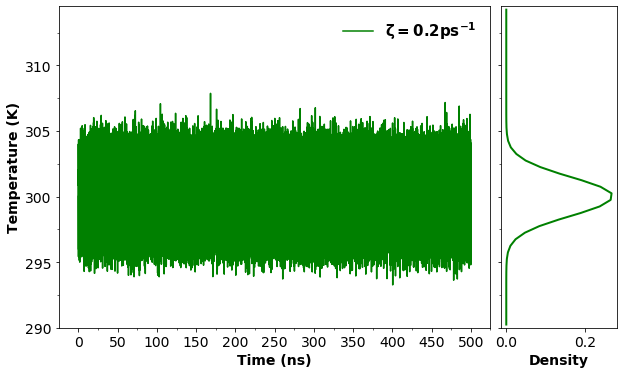

In [24]:
UBQ_TEMP_NVT_Cf20ps['Time'] = UBQ_TEMP_NVT_Cf20ps.index*0.0005
UBQ_TEMP_NVT_Cf2ps['Time'] = UBQ_TEMP_NVT_Cf2ps.index*0.0005
UBQ_TEMP_NVT_Cf02ps['Time'] = UBQ_TEMP_NVT_Cf02ps.index*0.0005
fig_nvt_comp_nvt2 = _plot_TempMarg_NVT(UBQ_TEMP_NVT_Cf02ps, UBQ_TEMP_NVT_Cf2ps, UBQ_TEMP_NVT_Cf20ps)
fig_nvt_comp_nvt2.savefig('{}{}/Analysis/CompareNVT_TemperatureRegulation_CutStart_nvt2.png'.format(CorrFuncLoc2,'Ubiquitin'), dpi=600, bbox_inches='tight')

In [106]:
histbins = np.arange(180, 315, 0.5)
hist_cf_list = []

for Tdata in [UBQ_TEMP_NVT_Cf02ps['Run1'].values, UBQ_TEMP_NVT_Cf02ps['Run1'].values, UBQ_TEMP_NVT_Cf20ps['Run1'].values]:
    hist_cf, edges = np.histogram(Tdata, bins=histbins, density=True)
    hist_cf_list.append(hist_cf)

fighist, axhists = plt.subplots(1,1, figsize=(6,8))
edges = 0.5*(histbins[1:]+histbins[:-1])
for hists in hist_cf_list:
    axhists.plot(hists, edges)

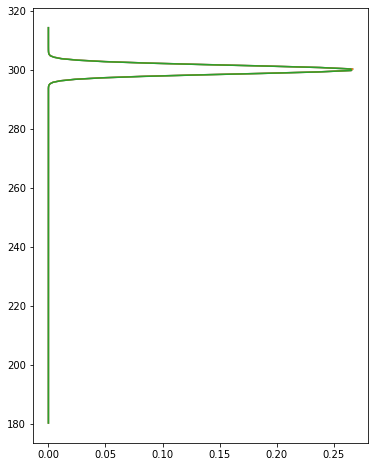

In [ ]:
NVT_TSeries_Temp = pd.read_fwf('{}{}/PROD_NVT/CF0-2ps/Run4/TEMP_MDOUT.dat'.format(CorrFuncLoc2,'Ubiquitin'), header=None,
                               usecols=[5,8],names=[''])

In [ ]:
NVT_TSeries_Temp

In [ ]:
NVT_TSeries_Temp[NVT_TSeries_Temp['TEMP(K)'] == r'\x00\x00\x00\x00\x00\x00']

In [ ]:
NVT_TSeries_Temp

In [ ]:
TEMP_NVT = pd.read_csv('{}{}/PROD_NVT/CF0-2ps/Run4/TEMP_MDOUT.dat'.format(CorrFuncLoc2,'Ubiquitin'),
                      delim_whitespace=True, usecols=[2,3,4,5,6,7,8])

In [ ]:
TEMP_NVT

In [ ]:
NSTEPS = 500
cumsum = np.cumsum(np.insert(GB3_TEMP_NVE_R2['Run2'].values, 0, 0)) 
roll_mean = (cumsum[NSTEPS:] - cumsum[:-NSTEPS])/NSTEPS

In [ ]:
plt.plot(roll_mean)

In [ ]:
temp_tseries = pd.read_csv('{}{}/TEMP_MDOUT.dat'.format(DIR,RUNS[0]), delim_whitespace=True)

In [ ]:
temp_tseries

In [ ]:
split_mask = TEMP_NVT['=.1'] != '='

In [ ]:
TEMP_NVT[split_mask].iloc[0,3]

In [ ]:
temp_tseries_extract = pd.DataFrame(index=TEMP_NVT.index, columns=['TIME(PS)','TEMP(K)'])

while True:
    try:
        split_mask = TEMP_NVT['=.1'] != '='
        
        fconv=3
        temp_tseries_extract.loc[TEMP_NVT[~split_mask].index, 'TIME(PS)'] = TEMP_NVT[~split_mask].iloc[:,fconv].astype('float64')
        fconv=6
        temp_tseries_extract.loc[TEMP_NVT[~split_mask].index, 'TEMP(K)'] = TEMP_NVT[~split_mask].iloc[:,fconv].astype('float64')
        
        fconv=2 ## TEMPDATA
        temp_tseries_extract.loc[TEMP_NVT[split_mask].index,'TIME(PS)'] = TEMP_NVT[split_mask].iloc[:-2,fconv].astype('float64')
        fconv=5 ## TEMPDATA
        temp_tseries_extract.loc[TEMP_NVT[split_mask].index,'TEMP(K)'] = TEMP_NVT[split_mask].iloc[:-2,fconv].astype('float64')
        
        break;
    
    except ValueError as verr:
        print('incorrect value in tseries: Can not convert to float')
        print(verr)
        interupt = str(verr).split(':')[-1] 
        interupt_mask = TEMP_NVT[split_mask].iloc[:,fconv][TEMP_NVT[split_mask].iloc[:,fconv] == str(interupt)[2:-1]].index
        
        TEMP_NVT = TEMP_NVT.drop(interupt_mask)

In [ ]:
temp_tseries_extract.dropna()

In [ ]:
TEMP_NVT

In [ ]:
TEMP_NVT[split_mask].iloc[:,fconv][TEMP_NVT[split_mask].iloc[:,fconv] == str(interupt)[2:-1]].index

In [ ]:
temp_tseries_extract = pd.DataFrame(index=TEMP_NVT.index, columns=['TIME(PS)','TEMP(K)'])
temp_tseries_extract.loc[TEMP_NVT[~split_mask].index, 'TIME(PS)'] = TEMP_NVT[~split_mask].iloc[:,3].astype('float64')
temp_tseries_extract.loc[TEMP_NVT[~split_mask].index, 'TEMP(K)'] = TEMP_NVT[~split_mask].iloc[:,6].astype('float64')

temp_tseries_extract.loc[TEMP_NVT[split_mask].index,'TIME(PS)'] = TEMP_NVT[split_mask].iloc[:-2,2].astype('float64')
temp_tseries_extract.loc[TEMP_NVT[split_mask].index,'TEMP(K)'] = TEMP_NVT[split_mask].iloc[:-2,5].astype('float64')
temp_tseries_extract = temp_tseries_extract.dropna()

In [ ]:
NVT_TSeries_Temp.iloc[5:-2,8].plot.hist(bins=50)
temp_tseries_extract['TEMP(K)'].iloc[5:-1].plot.hist(bins=50)

In [ ]:
temp_tseries_extract.astype('float64').plot(x='TIME(PS)', y='TEMP(K)')
temp_tseries_extract.rolling(10000).mean().plot(y='TEMP(K)',ax=plt.gca())

In [ ]:
temp_tseries_extract.rolling(10000).mean().plot(y='TEMP(K)',ax=plt.gca())

In [ ]:
temp_tseries_extract

In [ ]:
EnergyTSeries = pd.read_csv('{}{}/Energy_MDOUT.dat'.format(DIR,RUNS[0]), delim_whitespace=True,
            header=None, usecols=[2,5,8], names=['Etot', 'E_Kinetic','E_Pot']).iloc[:-2]

In [ ]:
EnergyTSeries

In [ ]:
EnergyTSeries.iloc[0]-EnergyTSeries.iloc[-1]